# 02B. LDA, QDA oraz SVM/SVC — krótki dodatek klasyfikacyjny

**Czas podstawowy:** około 60–90 minut  
**Tryb pracy:** teoria → pseudokod → krótki `TODO` → autotest → interpretacja.

Ten notebook jest dodatkiem do głównego ciągu zajęć. Łączy wcześniejsze pojęcia macierzy odległości i podobieństwa z klasyfikacją nadzorowaną.

## Cele

Po wykonaniu notebooka powinieneś umieć:

- wyjaśnić, na czym opierają się LDA i QDA,
- rozróżnić wspólną macierz kowariancji od macierzy kowariancji osobnych dla klas,
- wyjaśnić hiperpłaszczyznę, margines oraz wektory wspierające SVM,
- rozumieć, że `SVC` jest klasyfikatorem realizującym ideę SVM,
- zbudować macierz podobieństwa jądra RBF,
- wskazać, kiedy lepiej działa LDA, QDA, liniowy SVM albo SVM z jądrem RBF.

## Mapa obiektów macierzowych

| Metoda | Najważniejszy obiekt | Rola |
|---|---|---|
| LDA | wspólna macierz kowariancji $\Sigma$ oraz macierze rozrzutu $S_W$, $S_B$ | liniowy podział klas i nadzorowana projekcja |
| QDA | osobna macierz kowariancji $\Sigma_k$ dla każdej klasy | zakrzywiona, kwadratowa granica decyzyjna |
| liniowy SVM | iloczyny skalarne i wektor $w$ | hiperpłaszczyzna o możliwie szerokim marginesie |
| kernel SVM | macierz Grama/podobieństwa $K_{ij}=K(x_i,x_j)$ | nieliniowy podział bez jawnego konstruowania nowych cech |

W przeciwieństwie do MDS, t-SNE i UMAP są to metody **nadzorowane**: podczas uczenia korzystają z etykiet klas $y$.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import make_moons, load_iris
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.metrics import accuracy_score, pairwise_distances, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 30)


def plot_points(X, y, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(X[:, 0], X[:, 1], c=y, s=34, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(alpha=0.2)
    return ax


def plot_decision_surface(model, X, y, title, ax=None, support_indices=None):
    # Rysuje obszary predykcji i granicę/margines.
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    pad = 0.8
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 260),
        np.linspace(y_min, y_max, 260),
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    predicted = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, predicted, alpha=0.16)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, alpha=0.82)

    if hasattr(model, "decision_function"):
        decision = model.decision_function(grid)
        if np.ndim(decision) == 1:
            decision = decision.reshape(xx.shape)
            try:
                ax.contour(xx, yy, decision, levels=[-1, 0, 1], linewidths=[1, 2, 1])
            except ValueError:
                pass

    if support_indices is not None and len(support_indices):
        support_points = X[np.asarray(support_indices)]
        ax.scatter(
            support_points[:, 0], support_points[:, 1],
            s=110, facecolors="none", edgecolors="black", linewidths=1.3,
            label="wektory wspierające",
        )
        ax.legend(loc="best")

    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(alpha=0.18)
    return ax


def evaluate_binary_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    return {
        "model": name,
        "accuracy_train": accuracy_score(y_train, model.predict(X_train)),
        "accuracy_test": accuracy_score(y_test, model.predict(X_test)),
    }


## 1. LDA — Linear Discriminant Analysis

LDA można rozumieć na dwa zgodne sposoby:

1. jako klasyfikator z liniową granicą decyzyjną,
2. jako nadzorowaną redukcję wymiaru, która szuka kierunków dobrze rozdzielających klasy.

Zakładamy, że klasy mają różne średnie $\mu_k$, ale tę samą macierz kowariancji $\Sigma$:

$$
X\mid y=k \sim \mathcal{N}(\mu_k,\Sigma).
$$

Dla dwóch klas najważniejszy kierunek ma postać:

$$
w=\Sigma^{-1}(\mu_1-\mu_0).
$$

Punkt jest klasyfikowany na podstawie znaku funkcji:

$$
f(x)=w^Tx+b.
$$

Dla jednakowych prawdopodobieństw klas:

$$
b=-\frac{1}{2}(\mu_1+\mu_0)^Tw.
$$

### Połączenie z macierzami

LDA nie rozpoczyna od macierzy sąsiedztwa. Korzysta z:

- średnich klas,
- wspólnej macierzy kowariancji,
- macierzy rozrzutu wewnątrz klas $S_W$,
- macierzy rozrzutu między klasami $S_B$.

Dla redukcji wymiaru szuka kierunków maksymalizujących stosunek rozdzielenia klas do rozrzutu wewnątrz klas.


### Dane 1: dwie klasy o podobnym kształcie

Najpierw tworzymy klasy o tej samej macierzy kowariancji. Jest to sytuacja sprzyjająca LDA.


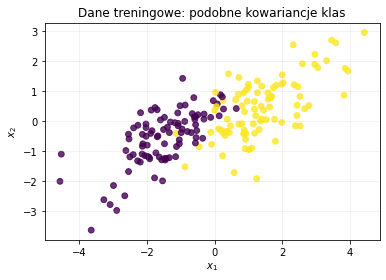

In [2]:
rng_lda = np.random.default_rng(RANDOM_STATE)

cov_shared = np.array([
    [1.00, 0.65],
    [0.65, 1.00],
])

X0 = rng_lda.multivariate_normal([-1.5, -0.5], cov_shared, size=130)
X1 = rng_lda.multivariate_normal([ 1.5,  0.5], cov_shared, size=130)

X_lda = np.vstack([X0, X1])
y_lda = np.concatenate([
    np.zeros(len(X0), dtype=int),
    np.ones(len(X1), dtype=int),
])

X_lda_train, X_lda_test, y_lda_train, y_lda_test = train_test_split(
    X_lda, y_lda,
    test_size=0.30,
    stratify=y_lda,
    random_state=RANDOM_STATE,
)

plot_points(X_lda_train, y_lda_train, "Dane treningowe: podobne kowariancje klas")
plt.show()


## 2. `TODO 1` — policz ręcznie parametry LDA

Dla klas $0$ i $1$ policzymy:

1. średnie $\mu_0$ i $\mu_1$,
2. wspólną kowariancję $\Sigma$,
3. kierunek $w$,
4. wyraz wolny $b$.

Wspólną kowariancję estymujemy z obu klas:

$$
\Sigma
=
\frac{
\sum_{x_i\in C_0}(x_i-\mu_0)(x_i-\mu_0)^T
+
\sum_{x_i\in C_1}(x_i-\mu_1)(x_i-\mu_1)^T
}{n-2}.
$$

### Pseudokod

```text
X0_train = wiersze klasy 0
X1_train = wiersze klasy 1
mu0 = średnia X0_train po wierszach
mu1 = średnia X1_train po wierszach

S0 = (X0_train - mu0)^T @ (X0_train - mu0)
S1 = (X1_train - mu1)^T @ (X1_train - mu1)
Sigma = (S0 + S1) / (liczba_próbek - 2)

w = rozwiąż układ Sigma @ w = mu1 - mu0
b = -0.5 * (mu1 + mu0) @ w + log(prior1 / prior0)
```

### Pseudokod bliski NumPy

```python
X0_train = X_lda_train[y_lda_train == 0]
X1_train = X_lda_train[y_lda_train == 1]
mu0 = X0_train.mean(axis=0)
mu1 = X1_train.mean(axis=0)

centered0 = X0_train - mu0
centered1 = X1_train - mu1
S0 = centered0.T @ centered0
S1 = centered1.T @ centered1
Sigma = (S0 + S1) / (len(X_lda_train) - 2)

w_lda = np.linalg.solve(Sigma, mu1 - mu0)
b_lda = -0.5 * (mu1 + mu0) @ w_lda + np.log(prior1 / prior0)
```


In [3]:
X0_train = X_lda_train[y_lda_train == 0]
X1_train = X_lda_train[y_lda_train == 1]

mu0 = X0_train.mean(axis=0)
mu1 = X1_train.mean(axis=0)

centered0 = X0_train - mu0
centered1 = X1_train - mu1
S0 = centered0.T @ centered0
S1 = centered1.T @ centered1
Sigma_shared = (S0 + S1) / (len(X_lda_train) - 2)

prior0 = np.mean(y_lda_train == 0)
prior1 = np.mean(y_lda_train == 1)

w_lda = np.linalg.solve(Sigma_shared, mu1 - mu0)
b_lda = -0.5 * (mu1 + mu0) @ w_lda + np.log(prior1 / prior0)


In [4]:
# Autotest TODO 1
assert mu0 is not None and mu1 is not None, "Policz średnie klas."
assert Sigma_shared is not None and Sigma_shared.shape == (2, 2)
assert np.allclose(Sigma_shared, Sigma_shared.T)
assert np.all(np.linalg.eigvalsh(Sigma_shared) > 0)
assert w_lda is not None and np.asarray(w_lda).shape == (2,)
assert np.isfinite(b_lda)

print("mu0 =", np.round(mu0, 3))
print("mu1 =", np.round(mu1, 3))
print("\nWspólna kowariancja Sigma:")
display(pd.DataFrame(Sigma_shared, columns=["x1", "x2"], index=["x1", "x2"]).round(3))
print("w =", np.round(w_lda, 3))
print("b =", round(float(b_lda), 3))


mu0 = [-1.502 -0.556]
mu1 = [1.386 0.459]

Wspólna kowariancja Sigma:


,x1,x2
x1,1.098,0.668
x2,0.668,0.909


w = [ 3.53  -1.479]
b = 0.133


## 3. `TODO 2` — projekcja i ręczna klasyfikacja LDA

Każdy punkt można rzutować na kierunek dyskryminacyjny:

$$
z_i=x_i^Tw.
$$

Do klasyfikacji używamy pełnego wyniku:

$$
f(x_i)=x_i^Tw+b.
$$

Przyjmujemy:

$$
\hat{y}_i=
\begin{cases}
1,& f(x_i)\geq 0,\\
0,& f(x_i)<0.
\end{cases}
$$

### Pseudokod bliski NumPy

```python
scores_test = X_lda_test @ w_lda + b_lda
pred_manual_lda = (scores_test >= 0).astype(int)
accuracy_manual_lda = np.mean(pred_manual_lda == y_lda_test)
```


In [5]:
scores_test = X_lda_test @ w_lda + b_lda
pred_manual_lda = (scores_test >= 0).astype(int)
accuracy_manual_lda = np.mean(pred_manual_lda == y_lda_test)


Accuracy ręcznego LDA: 0.949
Accuracy sklearn LDA:  0.949
Macierz pomyłek:


,pred 0,pred 1
true 0,36,3
true 1,1,38


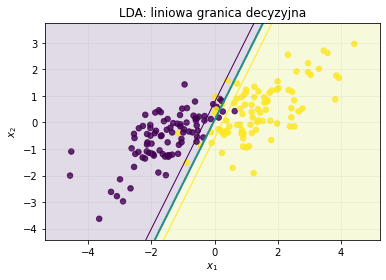

In [6]:
# Sprawdzenie z implementacją biblioteczną
lda_library = LinearDiscriminantAnalysis()
lda_library.fit(X_lda_train, y_lda_train)
pred_library_lda = lda_library.predict(X_lda_test)

assert scores_test is not None and pred_manual_lda is not None
assert accuracy_manual_lda is not None
assert accuracy_manual_lda >= 0.85
assert np.array_equal(pred_manual_lda, pred_library_lda), (
    "Ręczne LDA powinno dać te same predykcje co sklearn dla tego przykładu."
)

print(f"Accuracy ręcznego LDA: {accuracy_manual_lda:.3f}")
print(f"Accuracy sklearn LDA:  {accuracy_score(y_lda_test, pred_library_lda):.3f}")
print("Macierz pomyłek:")
display(pd.DataFrame(
    confusion_matrix(y_lda_test, pred_manual_lda),
    index=["true 0", "true 1"],
    columns=["pred 0", "pred 1"],
))

plot_decision_surface(
    lda_library,
    X_lda_train,
    y_lda_train,
    "LDA: liniowa granica decyzyjna",
)
plt.show()


### LDA jako nadzorowana redukcja wymiaru

Dla $K$ klas LDA może utworzyć maksymalnie $K-1$ wymiarów dyskryminacyjnych. W przeciwieństwie do PCA korzysta z etykiet klas.

Poniżej cztery cechy zbioru Iris zostają sprowadzone do dwóch wymiarów LDA.


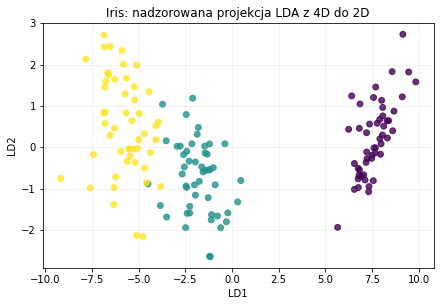

Kształt przed redukcją: (150, 4)
Kształt po redukcji: (150, 2)


In [7]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

lda_projection = LinearDiscriminantAnalysis(n_components=2)
X_iris_lda = lda_projection.fit_transform(X_iris, y_iris)

plt.figure(figsize=(7, 4.5))
plt.scatter(X_iris_lda[:, 0], X_iris_lda[:, 1], c=y_iris, s=35, alpha=0.8)
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Iris: nadzorowana projekcja LDA z 4D do 2D")
plt.grid(alpha=0.2)
plt.show()

print("Kształt przed redukcją:", X_iris.shape)
print("Kształt po redukcji:", X_iris_lda.shape)


## 4. QDA — Quadratic Discriminant Analysis

QDA rezygnuje z założenia wspólnej kowariancji. Każda klasa ma własną macierz:

$$
X\mid y=k \sim \mathcal{N}(\mu_k,\Sigma_k).
$$

Funkcja dyskryminacyjna klasy $k$ ma postać:

$$
\delta_k(x)
=
-\frac{1}{2}\log|\Sigma_k|
-\frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)
+\log\pi_k.
$$

Wybieramy klasę o największej wartości $\delta_k(x)$.

Ponieważ w wyrażeniu występuje forma kwadratowa, granica między klasami może być krzywa. QDA jest bardziej elastyczna niż LDA, ale estymuje więcej parametrów i przy małej liczbie obserwacji łatwiej się przeucza.


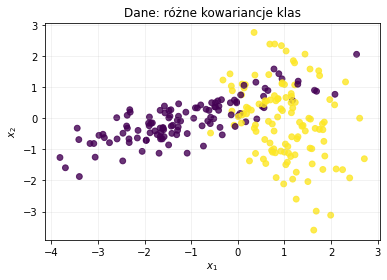

In [8]:
rng_qda = np.random.default_rng(11)

cov0_qda = np.array([
    [1.80, 0.75],
    [0.75, 0.50],
])
cov1_qda = np.array([
    [0.45, -0.15],
    [-0.15, 1.90],
])

X0_qda = rng_qda.multivariate_normal([-1.0, 0.0], cov0_qda, size=180)
X1_qda = rng_qda.multivariate_normal([ 1.0, 0.0], cov1_qda, size=180)

X_qda = np.vstack([X0_qda, X1_qda])
y_qda = np.concatenate([
    np.zeros(len(X0_qda), dtype=int),
    np.ones(len(X1_qda), dtype=int),
])

X_qda_train, X_qda_test, y_qda_train, y_qda_test = train_test_split(
    X_qda, y_qda,
    test_size=0.35,
    stratify=y_qda,
    random_state=RANDOM_STATE,
)

plot_points(X_qda_train, y_qda_train, "Dane: różne kowariancje klas")
plt.show()


## 5. `TODO 3` — ręczna funkcja wyniku QDA

Napisz funkcję zwracającą $\delta_k(x)$ dla wielu punktów.

### Pseudokod

```text
różnica = X - mu
logdet = log(wyznacznika Sigma)
rozwiąż Sigma @ z = różnica^T
część_kwadratowa = suma(różnica * z^T, po cechach)
wynik = -0.5*logdet - 0.5*część_kwadratowa + log(prior)
```

### Pseudokod bliski NumPy

```python
difference = X - mu
sign, logdet = np.linalg.slogdet(Sigma)
solved = np.linalg.solve(Sigma, difference.T).T
quadratic = np.sum(difference * solved, axis=1)
score = -0.5 * logdet - 0.5 * quadratic + np.log(prior)
```


In [9]:
def qda_discriminant(X, mu, Sigma, prior):
    difference = X - mu
    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        raise ValueError("Macierz kowariancji musi być dodatnio określona.")
    solved = np.linalg.solve(Sigma, difference.T).T
    quadratic = np.sum(difference * solved, axis=1)
    return -0.5 * logdet - 0.5 * quadratic + np.log(prior)


In [10]:
# Parametry klas liczone z treningu
qda_params = []
for class_id in [0, 1]:
    X_class = X_qda_train[y_qda_train == class_id]
    qda_params.append({
        "mu": X_class.mean(axis=0),
        "Sigma": np.cov(X_class, rowvar=False),
        "prior": len(X_class) / len(X_qda_train),
    })

scores_qda_manual = np.column_stack([
    qda_discriminant(
        X_qda_test,
        params["mu"],
        params["Sigma"],
        params["prior"],
    )
    for params in qda_params
])

assert scores_qda_manual is not None
assert scores_qda_manual.shape == (len(X_qda_test), 2)
assert np.isfinite(scores_qda_manual).all()

pred_qda_manual = np.argmax(scores_qda_manual, axis=1)
qda_library_check = QuadraticDiscriminantAnalysis()
qda_library_check.fit(X_qda_train, y_qda_train)
pred_qda_library_check = qda_library_check.predict(X_qda_test)

agreement = np.mean(pred_qda_manual == pred_qda_library_check)
print(f"Zgodność ręcznej QDA ze sklearn: {agreement:.3f}")
print(f"Accuracy ręcznej QDA: {accuracy_score(y_qda_test, pred_qda_manual):.3f}")
assert agreement > 0.99


Zgodność ręcznej QDA ze sklearn: 1.000
Accuracy ręcznej QDA: 0.881


## 6. `TODO 4` — LDA kontra QDA

Dopasuj oba modele do danych o różnych kowariancjach i porównaj wynik.

### Pseudokod bliski Pythonowi

```python
lda_unequal = LinearDiscriminantAnalysis()
qda_unequal = QuadraticDiscriminantAnalysis()

lda_unequal.fit(X_qda_train, y_qda_train)
qda_unequal.fit(X_qda_train, y_qda_train)

lda_accuracy = accuracy_score(y_qda_test, lda_unequal.predict(X_qda_test))
qda_accuracy = accuracy_score(y_qda_test, qda_unequal.predict(X_qda_test))
```


In [11]:
lda_unequal = LinearDiscriminantAnalysis()
qda_unequal = QuadraticDiscriminantAnalysis()

lda_unequal.fit(X_qda_train, y_qda_train)
qda_unequal.fit(X_qda_train, y_qda_train)

lda_accuracy_unequal = accuracy_score(y_qda_test, lda_unequal.predict(X_qda_test))
qda_accuracy_unequal = accuracy_score(y_qda_test, qda_unequal.predict(X_qda_test))


,model,accuracy_test
0,LDA,0.778
1,QDA,0.881


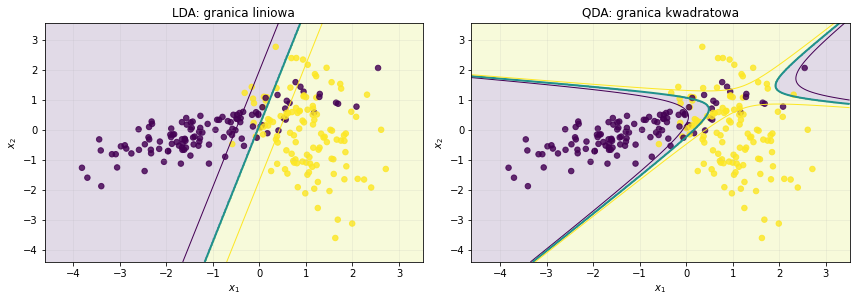

In [12]:
assert lda_unequal is not None and qda_unequal is not None
assert lda_accuracy_unequal is not None and qda_accuracy_unequal is not None
assert qda_accuracy_unequal > lda_accuracy_unequal

comparison_lda_qda = pd.DataFrame({
    "model": ["LDA", "QDA"],
    "accuracy_test": [lda_accuracy_unequal, qda_accuracy_unequal],
})
display(comparison_lda_qda.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
plot_decision_surface(
    lda_unequal, X_qda_train, y_qda_train,
    "LDA: granica liniowa", ax=axes[0],
)
plot_decision_surface(
    qda_unequal, X_qda_train, y_qda_train,
    "QDA: granica kwadratowa", ax=axes[1],
)
plt.tight_layout()
plt.show()


## 7. SVM i `SVC` — klasyfikacja przez maksymalny margines

**SVM** oznacza rodzinę metod Support Vector Machines.  
**SVC** to klasyfikacyjna implementacja SVM dostępna w `scikit-learn`.

Dla wariantu liniowego granica ma postać:

$$
w^Tx+b=0.
$$

SVM szuka granicy z możliwie szerokim marginesem. Szerokość między prostymi:

$$
w^Tx+b=-1
\qquad\text{oraz}\qquad
w^Tx+b=1
$$

wynosi:

$$
\frac{2}{\|w\|}.
$$

W miękkim marginesie rozwiązujemy problem:

$$
\min_{w,b,\xi}
\frac{1}{2}\|w\|^2+C\sum_i\xi_i,
$$

przy ograniczeniach:

$$
y_i(w^Tx_i+b)\geq 1-\xi_i,
\qquad
\xi_i\geq0.
$$

- małe $C$ mocniej preferuje szeroki margines i dopuszcza więcej naruszeń,
- duże $C$ mocniej karze błędy treningowe,
- tylko część punktów — **wektory wspierające** — bezpośrednio wyznacza granicę.

Dla SVM szczególnie ważna jest standaryzacja cech, ponieważ margines i jądra zależą od skali.


## 8. `TODO 5` — liniowy `SVC` i wektory wspierające

Użyjemy wcześniejszych danych LDA. Zbuduj potok:

$$
X\rightarrow \text{StandardScaler}\rightarrow \text{SVC liniowy}.
$$

### Pseudokod bliski Pythonowi

```python
svm_linear = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1.0),
)
svm_linear.fit(X_lda_train, y_lda_train)
pred = svm_linear.predict(X_lda_test)

svc_step = svm_linear.named_steps["svc"]
support_indices = svc_step.support_
```


In [13]:
svm_linear = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1.0),
)
svm_linear.fit(X_lda_train, y_lda_train)

pred_svm_linear = svm_linear.predict(X_lda_test)
accuracy_svm_linear = accuracy_score(y_lda_test, pred_svm_linear)
support_indices_linear = svm_linear.named_steps["svc"].support_


Accuracy liniowego SVC: 0.936
Liczba wektorów wspierających: 38 / 182


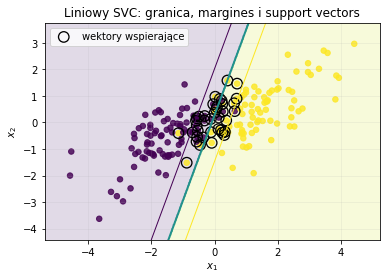

In [14]:
assert svm_linear is not None
assert pred_svm_linear is not None and len(pred_svm_linear) == len(y_lda_test)
assert accuracy_svm_linear >= 0.85
assert support_indices_linear is not None and len(support_indices_linear) > 0

print(f"Accuracy liniowego SVC: {accuracy_svm_linear:.3f}")
print(f"Liczba wektorów wspierających: {len(support_indices_linear)} / {len(X_lda_train)}")

plot_decision_surface(
    svm_linear,
    X_lda_train,
    y_lda_train,
    "Liniowy SVC: granica, margines i support vectors",
    support_indices=support_indices_linear,
)
plt.show()


## 9. `TODO 6` — co zmienia parametr $C$?

Uruchom liniowy `SVC` dla kilku wartości $C$ i zapisz:

- accuracy treningowe,
- accuracy testowe,
- liczbę wektorów wspierających.

### Pseudokod

```text
dla każdego C:
    utwórz StandardScaler + SVC(kernel="linear", C=C)
    dopasuj model
    policz accuracy train i test
    pobierz liczbę support vectors
    dopisz wiersz do tabeli
```

### Pseudokod bliski Pythonowi

```python
for C_value in C_grid:
    model = make_pipeline(StandardScaler(), SVC(kernel="linear", C=C_value))
    model.fit(X_train, y_train)
    n_support = len(model.named_steps["svc"].support_)
    rows.append({...})
```


In [15]:
C_grid = [0.03, 0.1, 0.3, 1.0, 10.0, 100.0]
rows_C = []
models_C = {}

for C_value in C_grid:
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C_value),
    )
    model.fit(X_lda_train, y_lda_train)
    models_C[C_value] = model
    rows_C.append({
        "C": C_value,
        "accuracy_train": accuracy_score(y_lda_train, model.predict(X_lda_train)),
        "accuracy_test": accuracy_score(y_lda_test, model.predict(X_lda_test)),
        "n_support_vectors": len(model.named_steps["svc"].support_),
    })

C_results = pd.DataFrame(rows_C)


,C,accuracy_train,accuracy_test,n_support_vectors
0,0.03,0.934,0.897,100
1,0.10,0.945,0.897,70
2,0.30,0.945,0.923,51
3,1.00,0.945,0.936,38
4,10.00,0.945,0.949,29
5,100.00,0.940,0.949,26


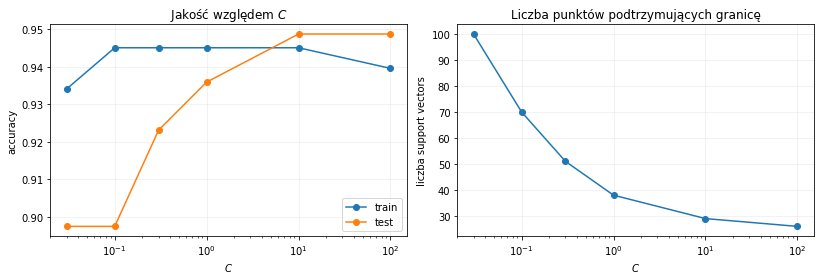

In [16]:
assert len(C_results) == len(C_grid)
assert set(["C", "accuracy_train", "accuracy_test", "n_support_vectors"]).issubset(C_results.columns)
assert C_results["n_support_vectors"].min() > 0

display(C_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(C_results["C"], C_results["accuracy_train"], marker="o", label="train")
axes[0].plot(C_results["C"], C_results["accuracy_test"], marker="o", label="test")
axes[0].set_xscale("log")
axes[0].set_xlabel("$C$")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Jakość względem $C$")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(C_results["C"], C_results["n_support_vectors"], marker="o")
axes[1].set_xscale("log")
axes[1].set_xlabel("$C$")
axes[1].set_ylabel("liczba support vectors")
axes[1].set_title("Liczba punktów podtrzymujących granicę")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 10. Jądro RBF jako macierz podobieństwa

Dla danych nieliniowych liniowa hiperpłaszczyzna może nie wystarczyć. SVM może korzystać z jądra, czyli funkcji podobieństwa.

Dla jądra RBF:

$$
K(x_i,x_j)
=
\exp\left(-\gamma\|x_i-x_j\|^2\right).
$$

Macierz:

$$
K_{ij}=K(x_i,x_j)
$$

jest macierzą Grama/podobieństwa:

- $K_{ij}$ bliskie $1$ oznacza bardzo podobne punkty,
- $K_{ij}$ bliskie $0$ oznacza punkty dalekie,
- $K_{ii}=1$.

To nawiązuje do ważonych macierzy podobieństwa z wcześniejszych notebooków. Różnica polega na celu:

- w UMAP/t-SNE podobieństwa służą do budowy embeddingu,
- w kernel SVM podobieństwa i etykiety służą do wyznaczenia granicy klas.

W postaci dualnej decyzja SVM zależy od support vectors:

$$
f(x)
=
\sum_{i\in SV}\alpha_i y_i K(x_i,x)+b.
$$


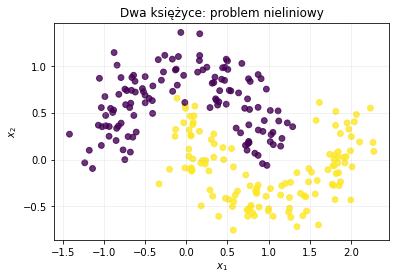

In [17]:
X_moons, y_moons = make_moons(
    n_samples=360,
    noise=0.18,
    random_state=RANDOM_STATE,
)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons,
    test_size=0.30,
    stratify=y_moons,
    random_state=RANDOM_STATE,
)

plot_points(X_moons_train, y_moons_train, "Dwa księżyce: problem nieliniowy")
plt.show()


## 11. `TODO 7` — zbuduj macierz podobieństwa RBF

Najpierw policz kwadraty odległości, a następnie zastosuj funkcję wykładniczą.

### Pseudokod bliski NumPy

```python
D2_train = pairwise_distances(X_moons_train, squared=True)
K_train = np.exp(-gamma_rbf * D2_train)

D2_test_train = pairwise_distances(
    X_moons_test,
    X_moons_train,
    squared=True,
)
K_test_train = np.exp(-gamma_rbf * D2_test_train)
```

Zwróć uwagę na kształty:

$$
K_{train}\in\mathbb{R}^{n_{train}\times n_{train}},
$$

$$
K_{test,train}\in\mathbb{R}^{n_{test}\times n_{train}}.
$$


In [18]:
gamma_rbf = 2.0
D2_train = pairwise_distances(X_moons_train, squared=True)
K_train = np.exp(-gamma_rbf * D2_train)

D2_test_train = pairwise_distances(
    X_moons_test,
    X_moons_train,
    squared=True,
)
K_test_train = np.exp(-gamma_rbf * D2_test_train)


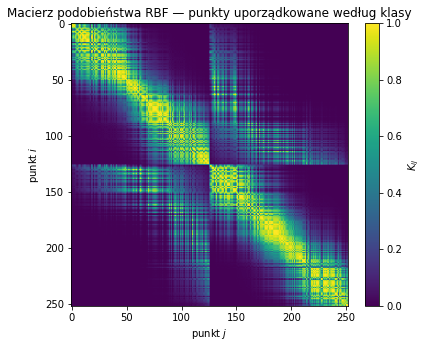

In [19]:
assert K_train is not None and K_test_train is not None
assert K_train.shape == (len(X_moons_train), len(X_moons_train))
assert K_test_train.shape == (len(X_moons_test), len(X_moons_train))
assert np.allclose(K_train, K_train.T)
assert np.allclose(np.diag(K_train), 1.0)
assert K_train.min() >= 0 and K_train.max() <= 1 + 1e-12

order = np.lexsort((X_moons_train[:, 0], y_moons_train))
K_ordered = K_train[np.ix_(order, order)]

plt.figure(figsize=(6.2, 5.2))
plt.imshow(K_ordered, aspect="auto")
plt.colorbar(label="$K_{ij}$")
plt.title("Macierz podobieństwa RBF — punkty uporządkowane według klasy")
plt.xlabel("punkt $j$")
plt.ylabel("punkt $i$")
plt.show()


## 12. `TODO 8` — `SVC` z gotową macierzą jądra

`SVC(kernel="precomputed")` przyjmuje zamiast surowych cech gotową macierz podobieństwa.

### Pseudokod bliski Pythonowi

```python
svc_precomputed = SVC(kernel="precomputed", C=C_rbf)
svc_precomputed.fit(K_train, y_moons_train)
pred_precomputed = svc_precomputed.predict(K_test_train)

svc_rbf = SVC(kernel="rbf", gamma=gamma_rbf, C=C_rbf)
svc_rbf.fit(X_moons_train, y_moons_train)
pred_rbf = svc_rbf.predict(X_moons_test)
```

Oba modele powinny dać te same wyniki, ponieważ korzystają z tego samego jądra.


In [20]:
C_rbf = 5.0

svc_precomputed = SVC(kernel="precomputed", C=C_rbf)
svc_precomputed.fit(K_train, y_moons_train)
pred_precomputed = svc_precomputed.predict(K_test_train)

svc_rbf = SVC(kernel="rbf", gamma=gamma_rbf, C=C_rbf)
svc_rbf.fit(X_moons_train, y_moons_train)
pred_rbf = svc_rbf.predict(X_moons_test)


Accuracy RBF SVC: 0.954
Support vectors: 25 / 252


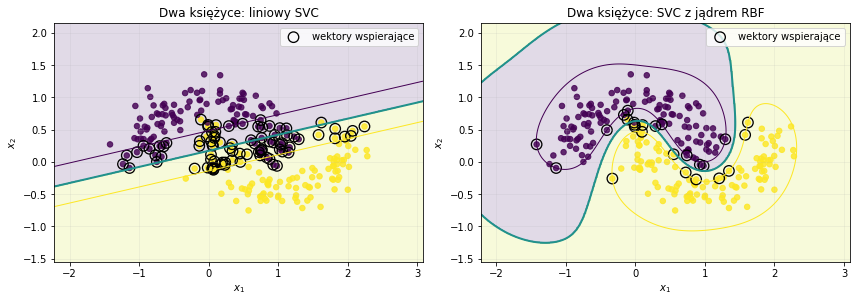

In [21]:
assert svc_precomputed is not None and svc_rbf is not None
assert pred_precomputed is not None and pred_rbf is not None
assert np.array_equal(pred_precomputed, pred_rbf)

accuracy_rbf = accuracy_score(y_moons_test, pred_rbf)
print(f"Accuracy RBF SVC: {accuracy_rbf:.3f}")
print(f"Support vectors: {len(svc_rbf.support_)} / {len(X_moons_train)}")

svm_moons_linear = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1.0),
)
svm_moons_linear.fit(X_moons_train, y_moons_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
plot_decision_surface(
    svm_moons_linear,
    X_moons_train,
    y_moons_train,
    "Dwa księżyce: liniowy SVC",
    ax=axes[0],
    support_indices=svm_moons_linear.named_steps["svc"].support_,
)
plot_decision_surface(
    svc_rbf,
    X_moons_train,
    y_moons_train,
    "Dwa księżyce: SVC z jądrem RBF",
    ax=axes[1],
    support_indices=svc_rbf.support_,
)
plt.tight_layout()
plt.show()


## 13. Porównanie metod na trzech typach danych

Sprawdzimy cztery modele:

1. LDA,
2. QDA,
3. liniowy SVC,
4. SVC z jądrem RBF.

Na trzech problemach:

1. klasy o podobnych kowariancjach — niemal liniowy podział,
2. klasy o różnych kowariancjach — przydatna granica kwadratowa,
3. dwa księżyce — struktura silnie nieliniowa.

Nie szukamy jednej metody „najlepszej zawsze”. Chcemy zobaczyć zgodność założeń modelu ze strukturą danych.


model,LDA,Linear SVC,QDA,RBF SVC
dataset,,,,
dwa księżyce,0.861,0.843,0.861,0.954
różne kowariancje,0.778,0.786,0.881,0.857
wspólna kowariancja,0.949,0.936,0.936,0.923


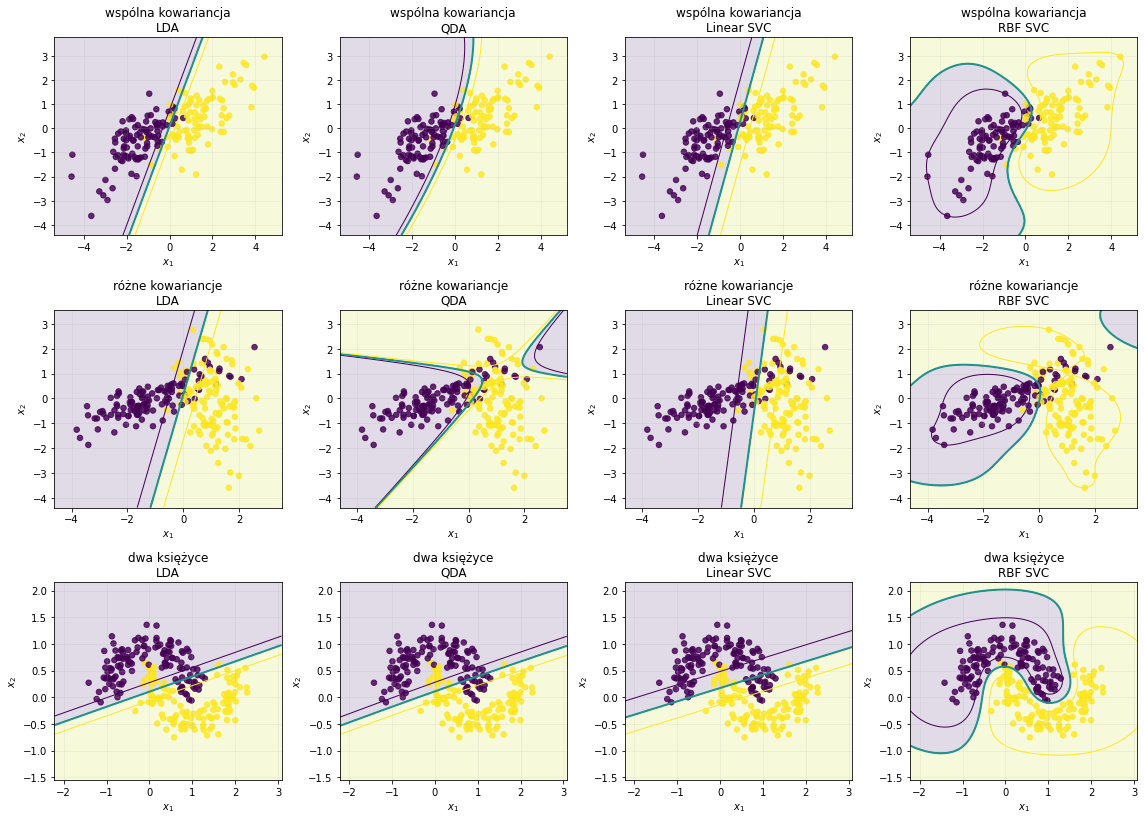

In [22]:
datasets_for_comparison = {
    "wspólna kowariancja": (X_lda_train, X_lda_test, y_lda_train, y_lda_test),
    "różne kowariancje": (X_qda_train, X_qda_test, y_qda_train, y_qda_test),
    "dwa księżyce": (X_moons_train, X_moons_test, y_moons_train, y_moons_test),
}

model_factories = {
    "LDA": lambda: LinearDiscriminantAnalysis(),
    "QDA": lambda: QuadraticDiscriminantAnalysis(reg_param=1e-4),
    "Linear SVC": lambda: make_pipeline(
        StandardScaler(), SVC(kernel="linear", C=1.0)
    ),
    "RBF SVC": lambda: make_pipeline(
        StandardScaler(), SVC(kernel="rbf", C=5.0, gamma="scale")
    ),
}

comparison_rows = []
fitted_for_plot = {}

for dataset_name, (X_train, X_test, y_train, y_test) in datasets_for_comparison.items():
    fitted_for_plot[dataset_name] = {}
    for model_name, factory in model_factories.items():
        model = factory()
        model.fit(X_train, y_train)
        fitted_for_plot[dataset_name][model_name] = model
        comparison_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "accuracy_test": accuracy_score(y_test, model.predict(X_test)),
        })

comparison_models = pd.DataFrame(comparison_rows)
display(
    comparison_models.pivot(
        index="dataset", columns="model", values="accuracy_test"
    ).round(3)
)

fig, axes = plt.subplots(3, 4, figsize=(16, 11.5))

for row_idx, (dataset_name, (X_train, _, y_train, _)) in enumerate(datasets_for_comparison.items()):
    for col_idx, model_name in enumerate(model_factories):
        plot_decision_surface(
            fitted_for_plot[dataset_name][model_name],
            X_train,
            y_train,
            f"{dataset_name}\n{model_name}",
            ax=axes[row_idx, col_idx],
        )

plt.tight_layout()
plt.show()


## 14. Najważniejsze wnioski

### LDA

- używa średnich klas i jednej wspólnej macierzy kowariancji,
- tworzy liniową granicę,
- jest dobrym, stabilnym punktem odniesienia,
- może także wykonywać nadzorowaną redukcję wymiaru,
- najlepiej pasuje do klas o zbliżonym kształcie i rozrzucie.

### QDA

- używa osobnej macierzy kowariancji dla każdej klasy,
- może tworzyć zakrzywioną granicę,
- lepiej reaguje na różne kształty klas,
- potrzebuje więcej danych, ponieważ estymuje więcej parametrów.

### liniowy SVM/SVC

- nie zakłada rozkładu Gaussa,
- szuka hiperpłaszczyzny o dużym marginesie,
- granicę wyznaczają przede wszystkim support vectors,
- wymaga uwagi na skalę cech,
- nie rozwiąże dobrze problemu, którego nie da się rozdzielić liniowo.

### SVM/SVC z jądrem RBF

- wykorzystuje macierz podobieństwa $K$,
- potrafi tworzyć nieliniowe granice,
- parametr $\gamma$ określa lokalność podobieństwa,
- parametr $C$ kontroluje karę za błędy,
- zbyt duże $C$ lub $\gamma$ może prowadzić do przeuczenia.

## Powiązanie z wcześniejszym materiałem

$$
D_{ij}=\|x_i-x_j\|
\quad\Longrightarrow\quad
K_{ij}=\exp(-\gamma D_{ij}^2).
$$

To ta sama ogólna idea przejścia od odległości do podobieństwa, którą poznaliśmy przy ważonych grafach, t-SNE i UMAP. Zmienia się jednak cel optymalizacji:

- t-SNE i UMAP tworzą reprezentację $Y$ bez etykiet klas,
- SVM używa etykiet, aby znaleźć granicę decyzyjną.

## Pytania kontrolne

1. Dlaczego LDA ma liniową, a QDA kwadratową granicę?
2. Co oznacza support vector?
3. Jak małe i duże $C$ zmienia kompromis między marginesem a błędami?
4. Dlaczego macierz RBF jest macierzą podobieństwa?
5. Dlaczego liniowy SVC nie rozdziela dobrze dwóch księżyców?
6. Kiedy elastyczność QDA albo RBF SVC może stać się wadą?

## Dodatkowe zadania

- zmień $\gamma$ na `0.2`, `1`, `5`, `20` i obserwuj granicę RBF,
- dodaj szum do danych i sprawdź stabilność metod,
- wykonaj walidację krzyżową dla $C$ oraz $\gamma$,
- porównaj liczbę support vectors z liczbą wszystkich punktów,
- dla Iris porównaj klasyfikację LDA i wieloklasowego SVC.
